In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import rdkit
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric

## Dataset

In [5]:
from torch_geometric.datasets import MoleculeNet

dataset = MoleculeNet(root='./data/MoleculeNet', name='ESOL')
dataset

ESOL(1128)

In [7]:
print("Dataset type:", type(dataset))
print("Dataset features:", dataset.num_features)
print("Dataset target:", dataset.num_classes)
print("Dataset length:", dataset.len)
print("Dataset sample:", dataset[0])
print("Sample nodes:", dataset[0].num_nodes)
print("Sample edges:", dataset[0].num_edges)

Dataset type: <class 'torch_geometric.datasets.molecule_net.MoleculeNet'>
Dataset features: 9
Dataset target: 734
Dataset length: <bound method InMemoryDataset.len of ESOL(1128)>
Dataset sample: Data(x=[32, 9], edge_index=[2, 68], edge_attr=[68, 3], smiles='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O ', y=[1, 1])
Sample nodes: 32
Sample edges: 68


c:\Users\user\OneDrive\Desktop\GitHub\multimodal-learning-notes\env\Lib\site-packages\torch_geometric\data\in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


In [9]:
dataset[0].x

tensor([[8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 2, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 0, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 0],
        [6, 0, 2, 5, 0, 0, 2, 0, 0],
        [7, 0, 1, 5, 0, 0, 2, 0, 0],
        [6, 0, 3, 5, 0, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 3, 5, 1, 0, 3, 1, 1],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
        [8, 0, 2, 5, 1, 0, 4, 0, 0],
        [6, 0, 4, 5, 1, 0, 4, 0, 1],
 

In [10]:
dataset[0].edge_index.t()

tensor([[ 0,  1],
        [ 1,  0],
        [ 1,  2],
        [ 2,  1],
        [ 2,  3],
        [ 2, 30],
        [ 3,  2],
        [ 3,  4],
        [ 4,  3],
        [ 4,  5],
        [ 4, 26],
        [ 5,  4],
        [ 5,  6],
        [ 6,  5],
        [ 6,  7],
        [ 7,  6],
        [ 7,  8],
        [ 7, 24],
        [ 8,  7],
        [ 8,  9],
        [ 9,  8],
        [ 9, 10],
        [ 9, 20],
        [10,  9],
        [10, 11],
        [11, 10],
        [11, 12],
        [11, 14],
        [12, 11],
        [12, 13],
        [13, 12],
        [14, 11],
        [14, 15],
        [14, 19],
        [15, 14],
        [15, 16],
        [16, 15],
        [16, 17],
        [17, 16],
        [17, 18],
        [18, 17],
        [18, 19],
        [19, 14],
        [19, 18],
        [20,  9],
        [20, 21],
        [20, 22],
        [21, 20],
        [22, 20],
        [22, 23],
        [22, 24],
        [23, 22],
        [24,  7],
        [24, 22],
        [24, 25],
        [2

In [12]:
dataset[0].y

tensor([[-0.7700]])

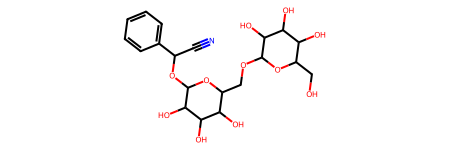

In [14]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole

molecule = Chem.MolFromSmiles(dataset[0].smiles)
molecule

In [15]:
type(molecule)

rdkit.Chem.rdchem.Mol

## Model

In [16]:
import torch
from torch.nn import Linear
import torch.nn.functional as F 
from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp
embedding_size = 64

class GCN(torch.nn.Module):
    def __init__(self):
        # Init parent
        super(GCN, self).__init__()
        torch.manual_seed(42)

        # GCN layers
        self.initial_conv = GCNConv(dataset.num_features, embedding_size)
        self.conv1 = GCNConv(embedding_size, embedding_size)
        self.conv2 = GCNConv(embedding_size, embedding_size)
        self.conv3 = GCNConv(embedding_size, embedding_size)

        # Output layer
        self.out = Linear(embedding_size*2, 1)

    def forward(self, x, edge_index, batch_index):
        # First Conv layer
        hidden = self.initial_conv(x, edge_index)
        hidden = F.tanh(hidden)

        # Other Conv layers
        hidden = self.conv1(hidden, edge_index)
        hidden = F.tanh(hidden)
        hidden = self.conv2(hidden, edge_index)
        hidden = F.tanh(hidden)
        hidden = self.conv3(hidden, edge_index)
        hidden = F.tanh(hidden)
          
        # Global Pooling (stack different aggregations)
        hidden = torch.cat([gmp(hidden, batch_index), 
                            gap(hidden, batch_index)], dim=1)

        # Apply a final (linear) classifier.
        out = self.out(hidden)

        return out, hidden

model = GCN()
print(model)
print("Number of parameters: ", sum(p.numel() for p in model.parameters()))

GCN(
  (initial_conv): GCNConv(9, 64)
  (conv1): GCNConv(64, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (out): Linear(in_features=128, out_features=1, bias=True)
)
Number of parameters:  13249


In [17]:
from torch_geometric.data import DataLoader
import warnings
warnings.filterwarnings("ignore")

# Root mean squared error
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007)  

# Use GPU for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Wrap data in a data loader
data_size = len(dataset)
NUM_GRAPHS_PER_BATCH = 64
loader = DataLoader(dataset[:int(data_size * 0.8)], 
                    batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)
test_loader = DataLoader(dataset[int(data_size * 0.8):], 
                         batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)

def train(loader):
    # Enumerate over the data
    for batch in loader:
      # Use GPU
      batch.to(device)  
      # Reset gradients
      optimizer.zero_grad() 
      # Passing the node features and the connection info
      pred, embedding = model(batch.x.float(), batch.edge_index, batch.batch) 
      # Calculating the loss and gradients
      loss = loss_fn(pred, batch.y)     
      loss.backward()  
      # Update using the gradients
      optimizer.step()   
    return loss, embedding

print("Starting training...")
losses = []
for epoch in range(2000):
    loss, h = train(loader)
    losses.append(loss)
    if epoch % 100 == 0:
      print(f"Epoch {epoch} | Train Loss {loss}")

Starting training...
Epoch 0 | Train Loss 11.665947914123535
Epoch 100 | Train Loss 0.8485183715820312
Epoch 200 | Train Loss 1.1155067682266235
Epoch 300 | Train Loss 0.3239014446735382
Epoch 400 | Train Loss 0.22367949783802032
Epoch 500 | Train Loss 0.3595080077648163
Epoch 600 | Train Loss 0.26092544198036194
Epoch 700 | Train Loss 0.06066801771521568
Epoch 800 | Train Loss 0.17027193307876587
Epoch 900 | Train Loss 0.12855160236358643
Epoch 1000 | Train Loss 0.04933073744177818
Epoch 1100 | Train Loss 0.04742930456995964
Epoch 1200 | Train Loss 0.10291331261396408
Epoch 1300 | Train Loss 0.03818747028708458
Epoch 1400 | Train Loss 0.033061858266592026
Epoch 1500 | Train Loss 0.011883744038641453
Epoch 1600 | Train Loss 0.052610669285058975
Epoch 1700 | Train Loss 0.01085197925567627
Epoch 1800 | Train Loss 0.06768165528774261
Epoch 1900 | Train Loss 0.05320174619555473


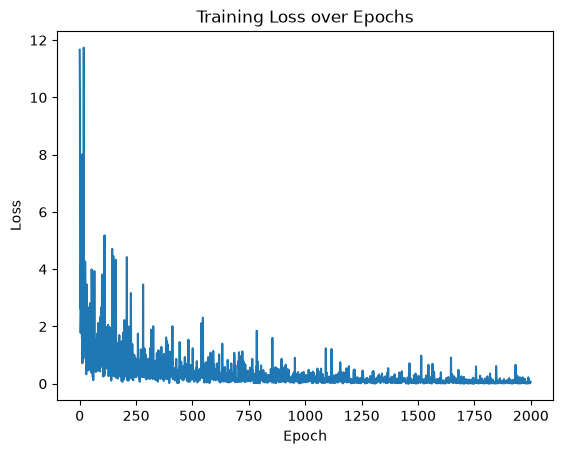

In [20]:
losses_float = [float(loss.cpu().detach().numpy()) for loss in losses]
loss_indices = [i for i, loss in enumerate(losses_float) if loss is not None]

sns.lineplot(
    x=loss_indices,
    y=[losses_float[i] for i in loss_indices]
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()

In [22]:
test_batch = next(iter(test_loader))
test_batch = test_batch.to(device)

with torch.no_grad():
    pred, embedding = model(
        test_batch.x.float(),
        test_batch.edge_index,
        test_batch.batch
    )

df = pd.DataFrame({
    "y_real": test_batch.y.detach().cpu().numpy().flatten(),
    "y_pred": pred.detach().cpu().numpy().flatten()
})

df

,y_real,y_pred
0,-2.570,-2.759778
1,-1.470,-1.060650
2,-5.410,-3.722932
3,0.610,-0.720625
4,-5.230,-3.678874
...,...,...
59,-1.920,-1.776901
60,-4.230,-3.616467
61,-4.554,-2.912313
62,-1.960,-1.356286


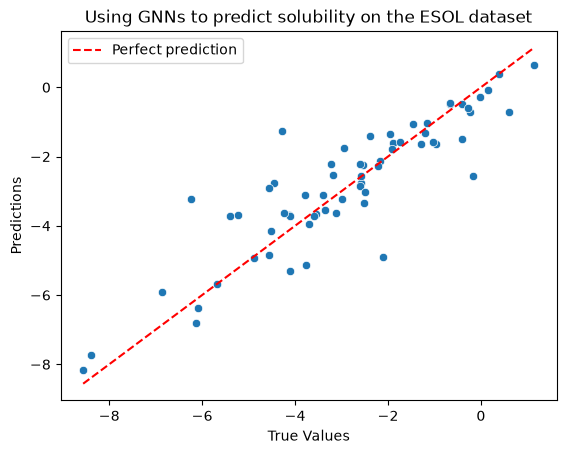

In [28]:
ax = sns.scatterplot(
    x='y_real',
    y='y_pred',
    data=df
)

min_val = min(df['y_real'].min(), df['y_pred'].min())
max_val = max(df['y_real'].max(), df['y_pred'].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    label='Perfect prediction'
)

ax.set(
    xlabel='True Values',
    ylabel='Predictions',
    title='Using GNNs to predict solubility on the ESOL dataset'
)

ax.legend()


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

y_true = df["y_real"].values
y_pred = df["y_pred"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
r, p = pearsonr(y_true, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"Pearson r: {r:.3f}")
print(f"p-value:   {p:.3e}")


MAE:  0.662
RMSE: 0.969
R²:   0.786
Pearson r: 0.888
p-value:   1.388e-22


In [30]:
df["error"] = df["y_pred"] - df["y_real"]
df["abs_error"] = df["error"].abs()

print(df["error"].describe())
print("MAE:", df["abs_error"].mean())
print("Error SD:", df["error"].std())


count    64.000000
mean      0.091068
std       0.972176
min      -2.787284
25%      -0.288611
50%       0.002761
75%       0.414579
max       3.021833
Name: error, dtype: float64
MAE: 0.66152173
Error SD: 0.9721759


AttributeError: 'Axes' object has no attribute 'xlabel'

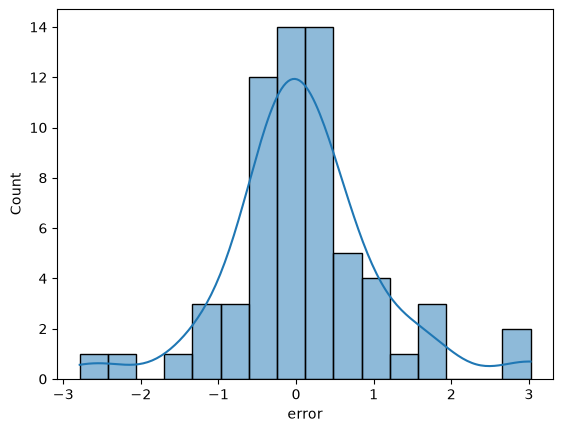

In [31]:
sns.histplot(df["error"], kde=True)

plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction error")
plt.title("Distribution of GNN prediction errors")
plt.show()


In [32]:
errors = np.abs(y_true - y_pred)

n_bootstrap = 10000
bootstrap_mae = []

for _ in range(n_bootstrap):
    sample = np.random.choice(
        errors,
        size=len(errors),
        replace=True
    )
    bootstrap_mae.append(sample.mean())

ci_lower = np.percentile(bootstrap_mae, 2.5)
ci_upper = np.percentile(bootstrap_mae, 97.5)

print(f"MAE: {errors.mean():.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")


MAE: 0.662
95% CI: [0.497, 0.842]
